In [8]:
# Cell 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set_theme(style="whitegrid")
%matplotlib inline

print("Libraries imported successfully.")

Libraries imported successfully.


In [9]:
# Cell 2: Load and Sample the Dataset
# Make sure 'Reviews.csv' is in your current working directory
raw_data = pd.read_csv('Reviews.csv')

# Sample 50,000 records to keep execution fast and efficient
df = raw_data.sample(n=50000, random_state=42).reset_index(drop=True)

print(f"Dataset loaded. Analysis dataset shape: {df.shape}")

Dataset loaded. Analysis dataset shape: (50000, 10)


In [10]:
# Cell 3: Structural Overview
print("--- Dataset Info ---")
print(df.info())

print("\n--- Missing Values ---")
print(df.isnull().sum())

print("\n--- First 3 Rows ---")
df.head(3)

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Id                      50000 non-null  int64 
 1   ProductId               50000 non-null  object
 2   UserId                  50000 non-null  object
 3   ProfileName             50000 non-null  object
 4   HelpfulnessNumerator    50000 non-null  int64 
 5   HelpfulnessDenominator  50000 non-null  int64 
 6   Score                   50000 non-null  int64 
 7   Time                    50000 non-null  int64 
 8   Summary                 49999 non-null  object
 9   Text                    50000 non-null  object
dtypes: int64(5), object(5)
memory usage: 3.8+ MB
None

--- Missing Values ---
Id                        0
ProductId                 0
UserId                    0
ProfileName               0
HelpfulnessNumerator      0
HelpfulnessDenominator    0

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,165257,B000EVG8J2,A1L01D2BD3RKVO,"B. Miller ""pet person""",0,0,5,1268179200,Crunchy & Good Gluten-Free Sandwich Cookies!,Having tried a couple of other brands of glute...
1,231466,B0000BXJIS,A3U62RE5XZDP0G,Marty,0,0,5,1298937600,great kitty treats,My cat loves these treats. If ever I can't fin...
2,427828,B008FHUFAU,AOXC0JQQZGGB6,Kenneth Shevlin,0,2,3,1224028800,COFFEE TASTE,A little less than I expected. It tends to ha...


/tmp/ipykernel_41529/2175966842.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Score', palette='viridis')


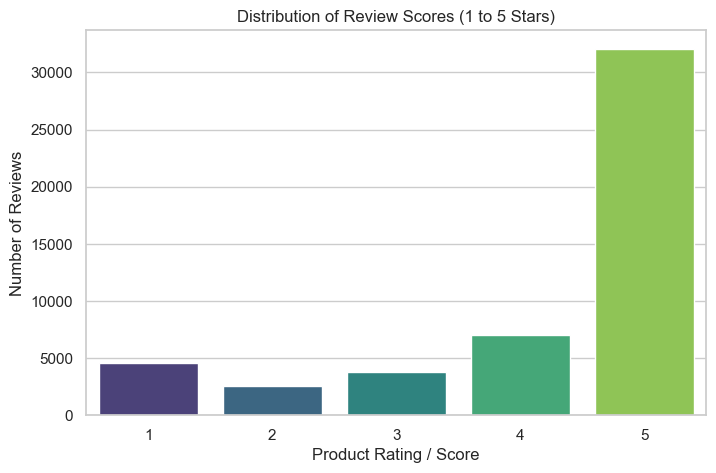

Percentage distribution of scores:
Score
1     9.056
2     5.152
3     7.582
4    14.016
5    64.194
Name: proportion, dtype: float64


In [11]:
# Cell 4: Distribution of Review Scores (Target Variable)
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Score', palette='viridis')
plt.title('Distribution of Review Scores (1 to 5 Stars)')
plt.xlabel('Product Rating / Score')
plt.ylabel('Number of Reviews')
plt.show()

# Print exact percentages
score_counts = df['Score'].value_counts(normalize=True) * 100
print("Percentage distribution of scores:")
print(score_counts.sort_index())


--- Review Text Word Count Statistics ---
count    50000.00000
mean        80.04868
std         79.20989
min          4.00000
25%         33.00000
50%         56.00000
75%         98.00000
max       1901.00000
Name: Review_Word_Count, dtype: float64


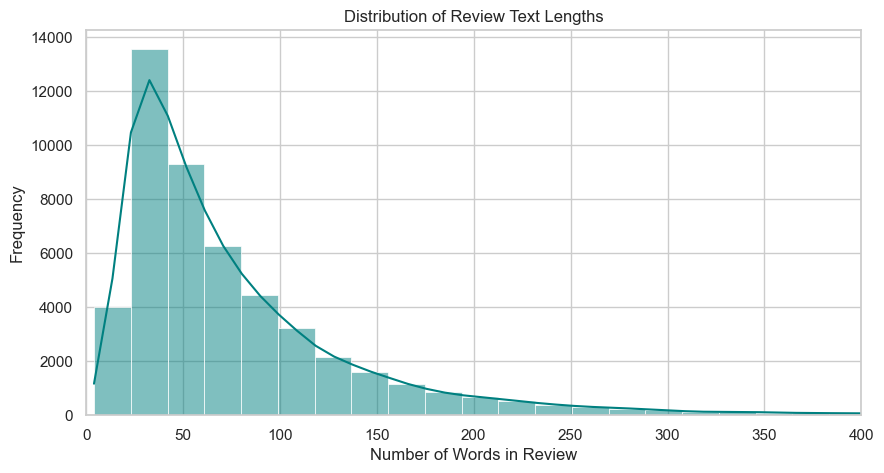

In [12]:
# Cell 5: Review Text Length Analysis
# Calculate the number of words in each review text
df['Review_Word_Count'] = df['Text'].apply(lambda x: len(str(x).split()))

print("--- Review Text Word Count Statistics ---")
print(df['Review_Word_Count'].describe())

# Plot the distribution of review lengths
plt.figure(figsize=(10, 5))
sns.histplot(df['Review_Word_Count'], bins=100, kde=True, color='teal')
plt.xlim(0, 400)  # Limiting x-axis to 400 words to cut out extreme outliers for better visibility
plt.title('Distribution of Review Text Lengths')
plt.xlabel('Number of Words in Review')
plt.ylabel('Frequency')
plt.show()

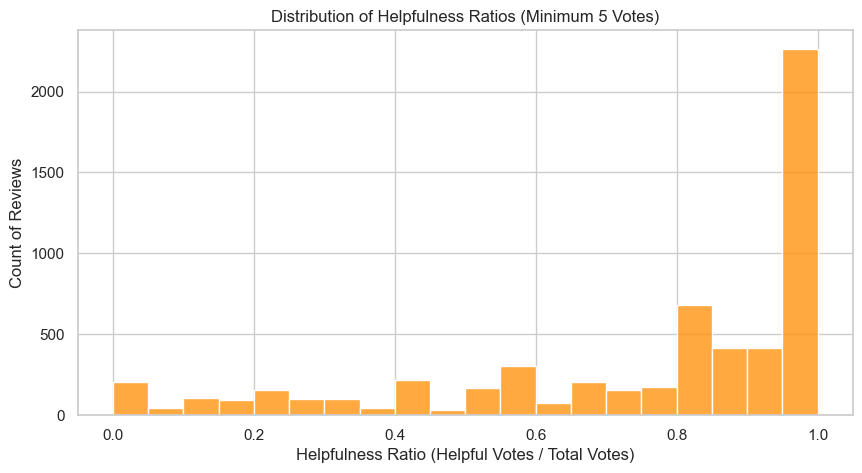

In [13]:
# Cell 7: Helpfulness Ratio Analysis
# HelpfulnessNumerator is the number of users who found the review helpful
# HelpfulnessDenominator is the number of users who voted on helpfulness
df['Helpfulness_Ratio'] = df['HelpfulnessNumerator'] / df['HelpfulnessDenominator']
df['Helpfulness_Ratio'] = df['Helpfulness_Ratio'].fillna(0) # Handle division by zero for unvoted reviews

# Filter reviews that have at least 5 total helpfulness votes to get stable ratios
voted_reviews = df[df['HelpfulnessDenominator'] >= 5]

plt.figure(figsize=(10, 5))
sns.histplot(voted_reviews['Helpfulness_Ratio'], bins=20, kde=False, color='darkorange')
plt.title('Distribution of Helpfulness Ratios (Minimum 5 Votes)')
plt.xlabel('Helpfulness Ratio (Helpful Votes / Total Votes)')
plt.ylabel('Count of Reviews')
plt.show()

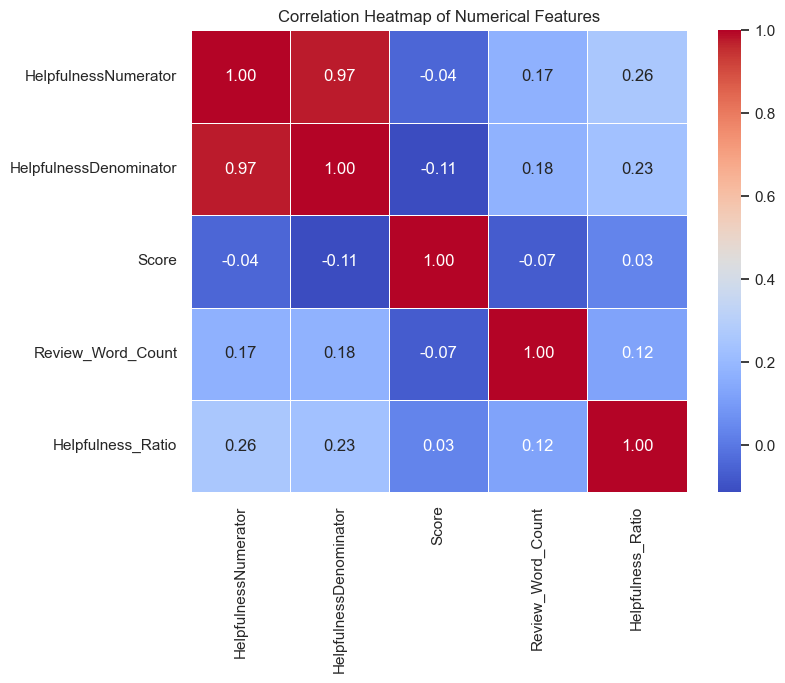

In [14]:
# Cell 8: Correlation Matrix (Numerical Features Only)
numerical_cols = ['HelpfulnessNumerator', 'HelpfulnessDenominator', 'Score', 'Review_Word_Count', 'Helpfulness_Ratio']
correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()